## Convert midi file into pandas dataframe
*same method also works with mido tracks or list of midi messages stored as dictionaries*

In [83]:
import pandas as pd
import mido

# can't iterate directly on midi file
# because it converts ticks to seconds
midi_file = mido.MidiFile('test.mid')
df = pd.DataFrame([
    # create a list of dictionaries which can be interpreted by pandas
    message.dict() for message in midi_file.tracks[0] if not message.is_meta
])
df


,type,time,note,velocity,channel,control,value
0,note_on,3240,72.0,36.0,0,NaN,NaN
1,note_on,2442,70.0,7.0,0,NaN,NaN
2,note_off,141,72.0,0.0,0,NaN,NaN
3,note_on,2693,66.0,71.0,0,NaN,NaN
4,note_off,36,70.0,0.0,0,NaN,NaN
...,...,...,...,...,...,...,...
10889,note_on,333,51.0,25.0,0,NaN,NaN
10890,note_off,69,54.0,0.0,0,NaN,NaN
10891,note_off,201,51.0,0.0,0,NaN,NaN
10892,note_on,148,49.0,39.0,0,NaN,NaN


## Wrangle dataframe

In [84]:
import numpy as np
from sklearn.impute import KNNImputer


# create a category type which enumarates labels in user defined order
type_names = ['note_on', 'note_off', 'control_change']
cat_type = pd.CategoricalDtype(type_names, ordered=True)
# create a new series with the category codes in new variable
wrangled_df = df
wrangled_df['type_codes'] = df['type'].astype(cat_type).cat.codes

# create a new series with shifted codes to use next code
# as current code and predict future
wrangled_df = wrangled_df.drop(['type', 'channel'], axis=1)
wrangled_df = pd.concat(
    # TODO check if it makes sense to use imputer 
    # instead of simple value replacement
    [wrangled_df, wrangled_df.shift(-1).add_prefix('next_')], axis=1
).drop(wrangled_df.tail(1).index)

imputer = KNNImputer(n_neighbors=2)
imputed_array = imputer.fit_transform(wrangled_df)
imputed_df = pd.DataFrame(imputed_array, columns=wrangled_df.columns).astype('int')

imputed_df



,time,note,velocity,control,value,type_codes,next_time,next_note,next_velocity,next_control,next_value,next_type_codes
0,3240,72,36,64,0,0,2442,70,7,36,64,0
1,2442,70,7,42,95,0,141,72,0,23,65,1
2,141,72,0,20,64,1,2693,66,71,64,0,0
3,2693,66,71,23,64,0,36,70,0,23,64,1
4,36,70,0,39,64,1,211,58,59,20,64,0
...,...,...,...,...,...,...,...,...,...,...,...,...
10888,109,56,0,23,65,1,333,51,25,42,32,0
10889,333,51,25,22,64,0,69,54,0,38,64,1
10890,69,54,0,36,63,1,201,51,0,52,64,1
10891,201,51,0,64,127,1,148,49,39,52,64,0


In [ ]:
wrangled_df.to_csv('test.csv')


## Create actual training data tables

In [86]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# take column to use as target for predictions
target = imputed_df['next_type_codes']


## Train KNN model for msg type parameter and test for accuracy
*KNN does support multioutput classification (not regression) but it's accuracy evaluation method does not*

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
# import SimpleImputer to replace NaN because not accepted in KNN
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

# test different settings
for n_neighbors in neighbors_settings:
    type_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    type_knn.fit(X_train, y_train)
    training_accuracy.append(type_knn.score(X_train, y_train))
    test_accuracy.append(type_knn.score(X_test, y_test))

# use best setting
ratios = []
i = 0
for x in training_accuracy:
    if training_accuracy[i] != 0:
        ratios.append(test_accuracy[i] / training_accuracy[i])
        i += 1

highest_score_index = ratios.index(max(ratios)) + 1
print(f'best score: {ratios.index(max(ratios)) + 1}')
type_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
type_knn.fit(X_train, y_train)

type_knn.predict(X_test).astype('int')


best score: 10


array([2, 2, 2, ..., 2, 0, 2], shape=(2724,))

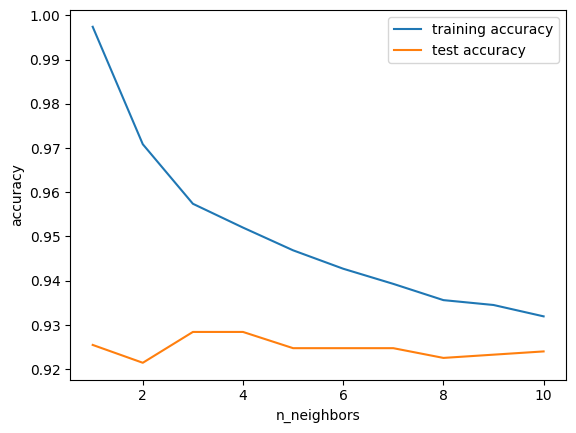

In [88]:
# plotting
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (Note value)

In [89]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data['next_type_codes'] = imputed_df['next_type_codes']
# take column to use as target for predictions
target = imputed_df['next_note']


## Train KNN model for note number parameter and test for accuracy

In [90]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

# test different settings
for n_neighbors in neighbors_settings:
    note_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    note_knn.fit(X_train, y_train)
    training_accuracy.append(note_knn.score(X_train, y_train))
    test_accuracy.append(note_knn.score(X_test, y_test))

# use best setting
ratios = []
i = 0
for x in training_accuracy:
    if training_accuracy[i] != 0:
        ratios.append(test_accuracy[i] / training_accuracy[i])
        i += 1

highest_score_index = ratios.index(max(ratios)) + 1
print(f'best score: {ratios.index(max(ratios)) + 1}')
note_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
note_knn.fit(X_train, y_train)

note_knn.predict(X_test).astype('int')


best score: 9


array([62, 58, 61, ..., 52, 55, 65], shape=(2724,))

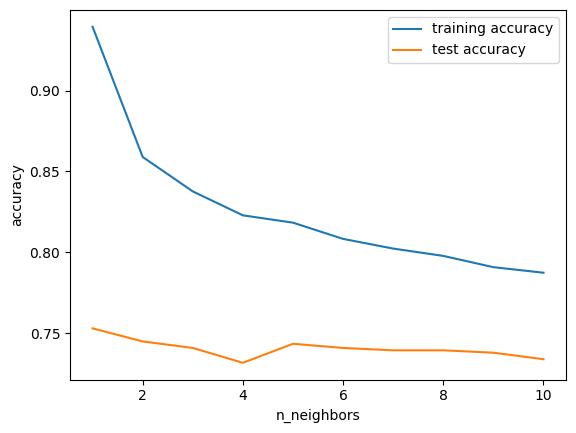

In [91]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (Note velocity)

In [92]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data[['next_type_codes', 'next_note']] = imputed_df[['next_type_codes', 'next_note']]
# take column to use as target for predictions
target = imputed_df['next_velocity']


## Train KNN model for note velocity parameter and test for accuracy

In [93]:
from sklearn.neighbors import KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

# test different settings
for n_neighbors in neighbors_settings:
    velocity_knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    velocity_knn.fit(X_train, y_train)
    training_accuracy.append(velocity_knn.score(X_train, y_train))
    test_accuracy.append(velocity_knn.score(X_test, y_test))

# use best setting
ratios = []
i = 0
for x in training_accuracy:
    if training_accuracy[i] != 0:
        ratios.append(test_accuracy[i] / training_accuracy[i])
        i += 1

highest_score_index = ratios.index(max(ratios)) + 1
print(f'best score: {ratios.index(max(ratios)) + 1}')
velocity_knn = KNeighborsRegressor(n_neighbors=highest_score_index)
velocity_knn.fit(X_train, y_train)

velocity_knn.predict(X_test).astype('int')


best score: 10


array([ 0, 32,  0, ...,  0, 44, 22], shape=(2724,))

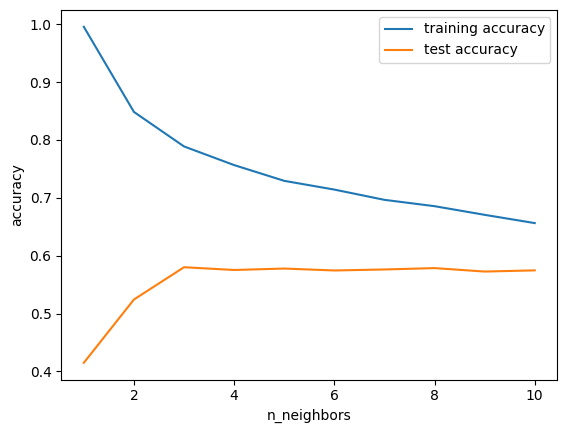

In [94]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (cc number)

In [95]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data['next_type_codes'] = imputed_df['next_type_codes']
# take column to use as target for predictions
target = imputed_df['next_control']


## Train KNN model for note number parameter and test for accuracy

In [96]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

# test different settings
for n_neighbors in neighbors_settings:
    control_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    control_knn.fit(X_train, y_train)
    training_accuracy.append(control_knn.score(X_train, y_train))
    test_accuracy.append(control_knn.score(X_test, y_test))

# use best setting
ratios = []
i = 0
for x in training_accuracy:
    if training_accuracy[i] != 0:
        ratios.append(test_accuracy[i] / training_accuracy[i])
        i += 1

highest_score_index = ratios.index(max(ratios)) + 1
print(f'best score: {ratios.index(max(ratios)) + 1}')
control_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
control_knn.fit(X_train, y_train)

control_knn.predict(X_test).astype('int')


best score: 10


array([55, 52, 20, ..., 53, 20, 21], shape=(2724,))

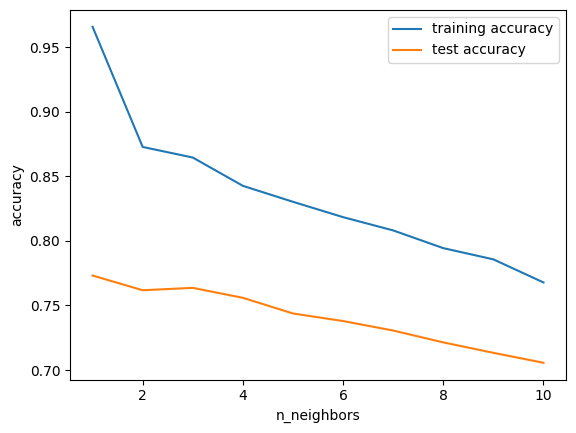

In [97]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (cc number)

In [98]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data[['next_type_codes', 'next_control']] = imputed_df[['next_type_codes', 'next_control']]
# take column to use as target for predictions
target = imputed_df['next_value']


## Train KNN model for note number parameter and test for accuracy

In [99]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

# test different settings
for n_neighbors in neighbors_settings:
    value_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    value_knn.fit(X_train, y_train)
    training_accuracy.append(value_knn.score(X_train, y_train))
    test_accuracy.append(value_knn.score(X_test, y_test))

# use best setting
ratios = []
i = 0
for x in training_accuracy:
    if training_accuracy[i] != 0:
        ratios.append(test_accuracy[i] / training_accuracy[i])
        i += 1

highest_score_index = ratios.index(max(ratios)) + 1
print(f'best score: {ratios.index(max(ratios)) + 1}')
value_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
value_knn.fit(X_train, y_train)

value_knn.predict(X_test).astype('int')


best score: 9


array([63, 65, 64, ..., 64, 67, 65], shape=(2724,))

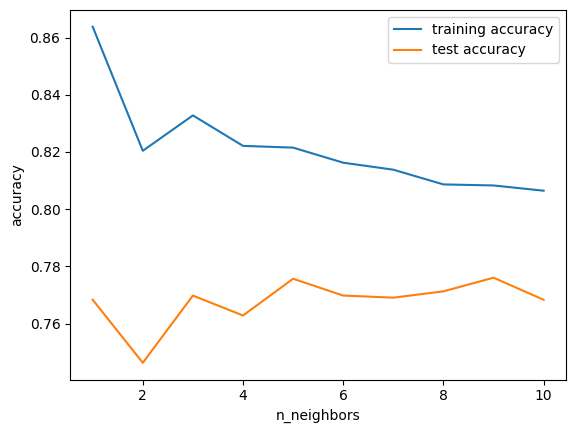

In [100]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (time)

In [101]:
# exclude second half of columns ('next_' values)
data = imputed_df.drop('next_time', axis=1)
# take column to use as target for predictions
target = imputed_df['next_time']


## Train KNN model for note number parameter and test for accuracy

In [102]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

# test different settings
for n_neighbors in neighbors_settings:
    time_knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    time_knn.fit(X_train, y_train)
    training_accuracy.append(time_knn.score(X_train, y_train))
    test_accuracy.append(time_knn.score(X_test, y_test))

# use best setting
ratios = []
i = 0
for x in training_accuracy:
    if training_accuracy[i] != 0:
        ratios.append(test_accuracy[i] / training_accuracy[i])
        i += 1

highest_score_index = ratios.index(max(ratios)) + 1
print(f'best score: {ratios.index(max(ratios)) + 1}')
time_knn = KNeighborsRegressor(n_neighbors=highest_score_index)
time_knn.fit(X_train, y_train)

time_knn.predict(X_test).astype('int')


best score: 10


array([14, 32,  1, ..., 30, 58, 56], shape=(2724,))

In [103]:
X_train


,time,note,velocity,control,value,type_codes,next_note,next_velocity,next_control,next_value,next_type_codes
811,21,67,0,20,64,2,62,12,20,65,2
4935,0,66,0,27,65,2,59,60,26,64,2
6452,28,67,19,26,64,2,65,0,26,65,2
8347,119,63,0,36,66,1,61,92,64,0,0
10470,0,71,0,22,66,2,59,23,22,64,2
...,...,...,...,...,...,...,...,...,...,...,...
8975,3,56,0,54,64,2,64,0,54,66,2
8471,42,63,16,53,64,2,58,16,53,65,2
6443,148,61,0,26,64,2,58,36,26,65,2
7309,448,59,16,58,64,2,59,33,58,65,2


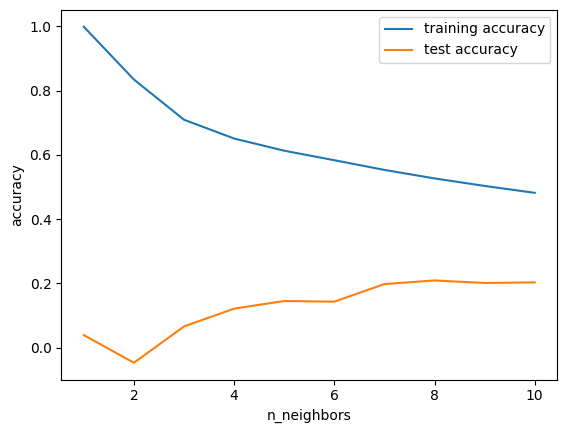

In [104]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Making complete prediction

In [ ]:
import mido
from sklearn.utils import shuffle

midi_file = mido.MidiFile()
midi_track = mido.MidiTrack()
midi_file.tracks.append(midi_track)
generated_msgs = []

# initialize
i = 0
random = np.random.randint(1, 20)
X_start = imputed_df.iloc[:1,:int(imputed_array.shape[1] / 2)]
for x in range(500):
    if i == random:
        X_start = imputed_df.iloc[[np.random.choice(imputed_df.shape[0])], :int(imputed_array.shape[1] / 2)]
        random = np.random.randint(1, 20)
        i = 0
        print(random)
    i += 1 
    X_new = X_start.copy()
    new_type = type_knn.predict(X_start).squeeze()
    X_new['next_type_codes'] = new_type
    new_control = control_knn.predict(X_new).squeeze()
    X_new['next_control'] = new_control
    new_value = value_knn.predict(X_new).squeeze()
    X_new.drop('next_control', axis=1, inplace=True)
    new_note = note_knn.predict(X_new).squeeze()
    X_new['next_note'] = new_note
    new_velocity = velocity_knn.predict(X_new).squeeze()
    X_new['next_velocity'] = new_velocity
    X_new['next_control'] = new_control
    X_new['next_value'] = new_value
    X_new.drop('next_type_codes', axis=1, inplace=True)
    X_new['next_type_codes'] = new_type
    new_time = time_knn.predict(X_new).squeeze()
    X_new['next_time'] = new_time
    X_new = X_new.iloc[:,int(imputed_array.shape[1] / 2):]
    X_new.columns = X_new.columns.str.removeprefix('next_')

    for col in X_start.columns:
        X_start[col] = X_new[col]

    new_msg = X_new.astype('int')
    new_msg['type'] = type_names[new_msg['type_codes'].iloc[-1]]
    new_msg.drop('type_codes', axis=1, inplace=True)
    new_msg = new_msg.to_dict(orient='records')[0]
    if new_msg['type'] in ['note_on', 'note_off']:
        new_msg.pop('control', None)
        new_msg.pop('value', None)
    elif new_msg['type'] == 'control_change':
        new_msg.pop('note', None)
        new_msg.pop('velocity', None)

    generated_msgs.append(new_msg.copy())

    midi_track.append(mido.Message(**new_msg))

midi_file.save('gen_test.mid')
df_generated = pd.DataFrame(generated_msgs)
df_generated.to_csv('gen_test.csv')


13
13
1
9
15
18
17
9
6
9
1
9
8
11
19
11
11
5
13
14
19
15
8
12
4
10
4
15
16
5
15
6
12
11
4
3
7
13
19
14
17
8
11
17
7
18


In [106]:

new_message = {
    'type': type_names[new_type]
}
new_message


{'type': 'control_change'}